In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score, f1_score,recall_score

from imblearn.over_sampling import SMOTE
from collections import Counter

import warnings
warnings.filterwarnings('ignore')



# Data Exploration

In [4]:
data = pd.read_csv(r'E:\ml_projects\diabetes_project\data\diabetes.csv')

In [5]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
data.duplicated().sum()

np.int64(0)

# Data Analysis

<Axes: >

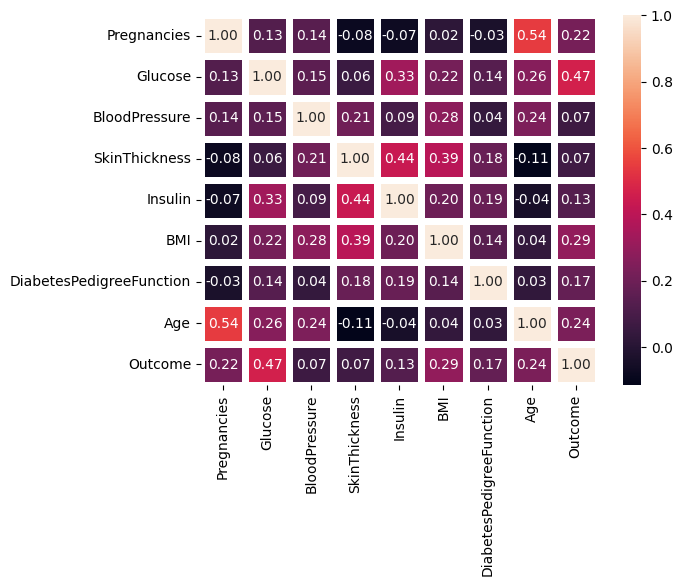

In [9]:
sns.heatmap(data.corr() , annot=True,fmt='0.2f',linewidths=5)

<Axes: xlabel='Outcome', ylabel='count'>

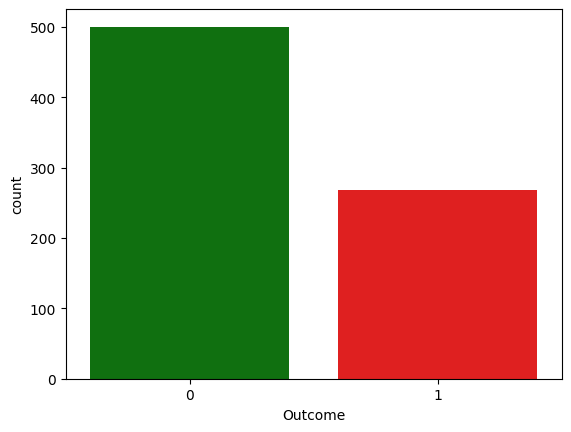

In [10]:
sns.countplot(x=data['Outcome'],palette=['g','r'])

Pregnancies                    Axes(0.125,0.653529;0.227941x0.226471)
Glucose                     Axes(0.398529,0.653529;0.227941x0.226471)
BloodPressure               Axes(0.672059,0.653529;0.227941x0.226471)
SkinThickness                  Axes(0.125,0.381765;0.227941x0.226471)
Insulin                     Axes(0.398529,0.381765;0.227941x0.226471)
BMI                         Axes(0.672059,0.381765;0.227941x0.226471)
DiabetesPedigreeFunction           Axes(0.125,0.11;0.227941x0.226471)
Age                             Axes(0.398529,0.11;0.227941x0.226471)
Outcome                         Axes(0.672059,0.11;0.227941x0.226471)
dtype: object

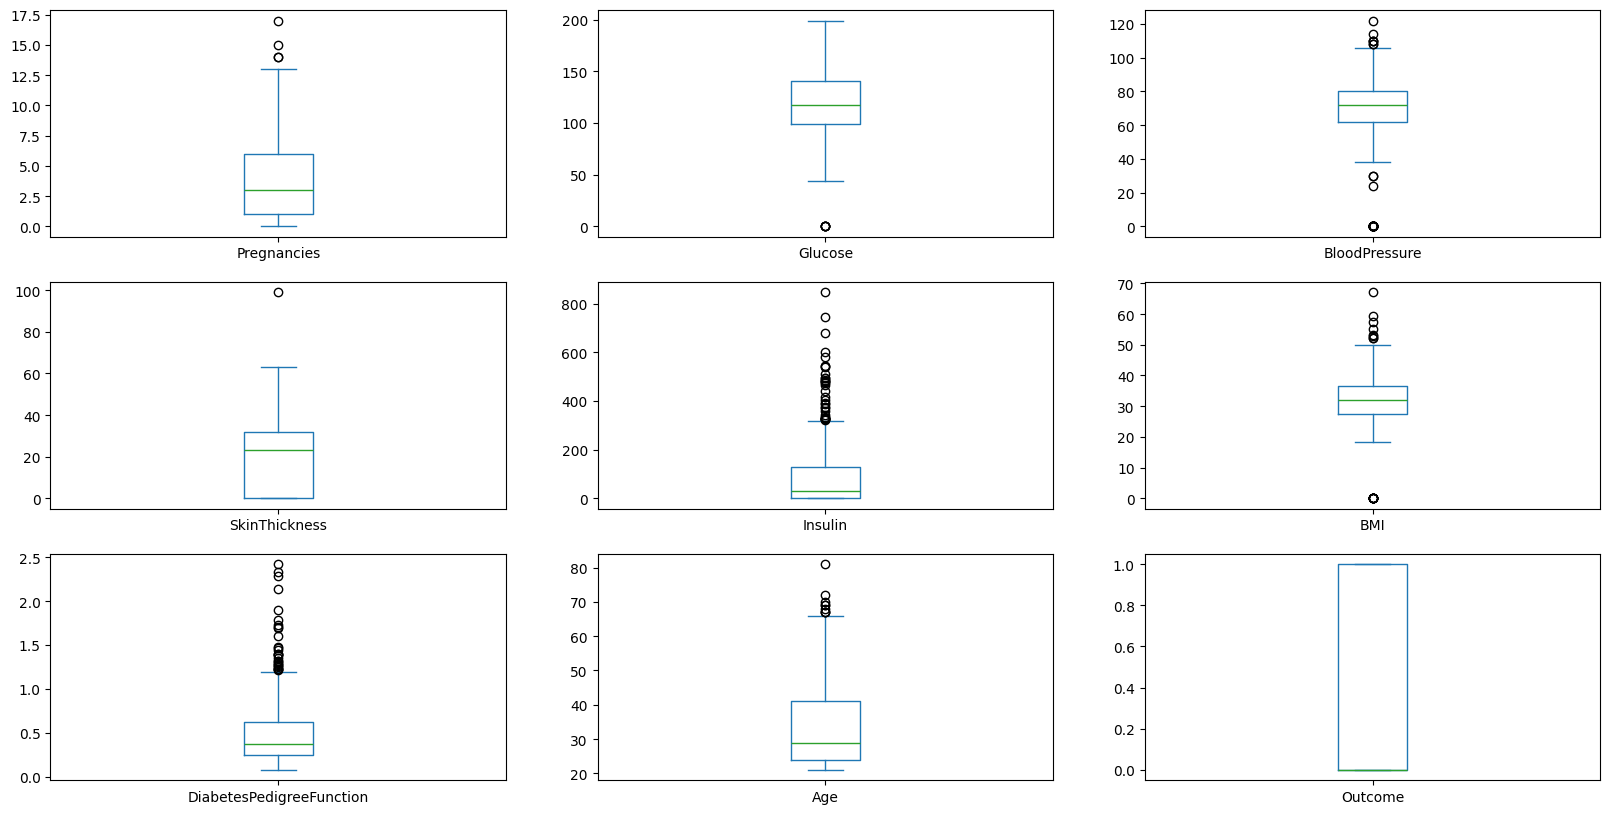

In [11]:
data.plot(
    kind='box',
    subplots=True,
    figsize=(20,10),
    layout=(3,3)
)

# modeling

In [90]:
x = data.drop('Outcome',axis=1)
y= data['Outcome'] 

In [91]:
sm = SMOTE(random_state=42)
x_res,y_res = sm.fit_resample(x,y)

In [92]:
print(f'old data: {Counter(y)}')
print(f'new data: {Counter(y_res)}')

old data: Counter({0: 500, 1: 268})
new data: Counter({1: 500, 0: 500})


In [93]:
x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [118]:
model1 = LogisticRegression()
model2 = SVC()
model3 = RandomForestClassifier(class_weight='balanced')
model4 = XGBClassifier() 
models_name = ['LogisticRegression','SVC','RandomForest','XgBoost']

In [119]:
params = {
    'n_estimators':[100,200,500,1000],
    'max_depth': [5,8, 10, None]
}
params_boost = {
    'n_estimators':[100,200,500,1000],
    'max_depth': [5,8, 10, None],
    'learning_rate': [0.1,0.01, 0.05],
}
model3 = GridSearchCV(model3,params,cv=3)
model4 = GridSearchCV(model4,params_boost,cv=3)

In [120]:

result4 = []
accuarcy_train_score = []
accuarcy_test_score = []
f1_train_score = []
f1_test_score = []
recall_train_score = []
recall_test_score = []

def TrainModel(model):
    model.fit(x_train,y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    accuarcy_test_score.append(accuracy_score(y_test,y_test_pred))
    f1_test_score.append(f1_score(y_test,y_test_pred))
    recall_test_score.append(recall_score(y_test,y_test_pred))
    result4.append(confusion_matrix(y_test,y_test_pred))

    accuarcy_train_score.append(accuracy_score(y_train,y_train_pred))
    f1_train_score.append(f1_score(y_train,y_train_pred))
    recall_train_score.append(recall_score(y_train,y_train_pred))


In [121]:
TrainModel(model1)
TrainModel(model2)
TrainModel(model3)
TrainModel(model4)

# evaluation

In [122]:
pd.DataFrame({
    'Models':models_name,
    'accuarcy':accuarcy_test_score,
    'f1_score':f1_test_score,
    'recall':recall_test_score,
})

,Models,accuarcy,f1_score,recall
0,LogisticRegression,0.755,0.760976,0.772277
1,SVC,0.750,0.764151,0.801980
2,RandomForest,0.805,0.820276,0.881188
3,XgBoost,0.805,0.821918,0.891089


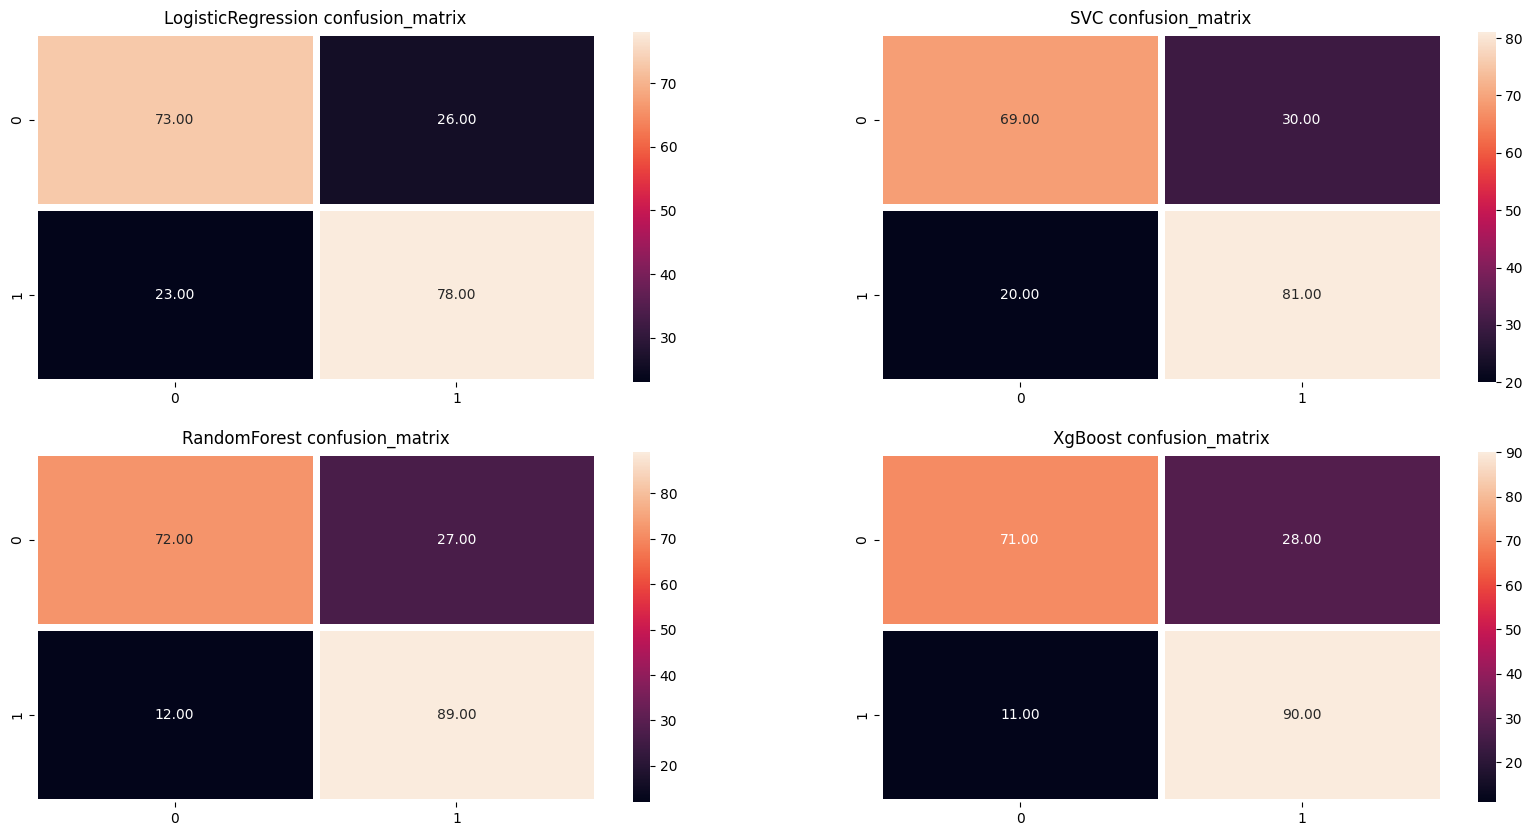

In [123]:
fig , ax = plt.subplots(2, 2, figsize=(20,10))

for i , cm in enumerate(result4):
    row = i //2
    col = i %2
    sns.heatmap(cm,annot=True,fmt='0.2f',linewidths=5,ax=ax[row,col])
    ax[row,col].set_title(models_name[i]+str(' confusion_matrix'))


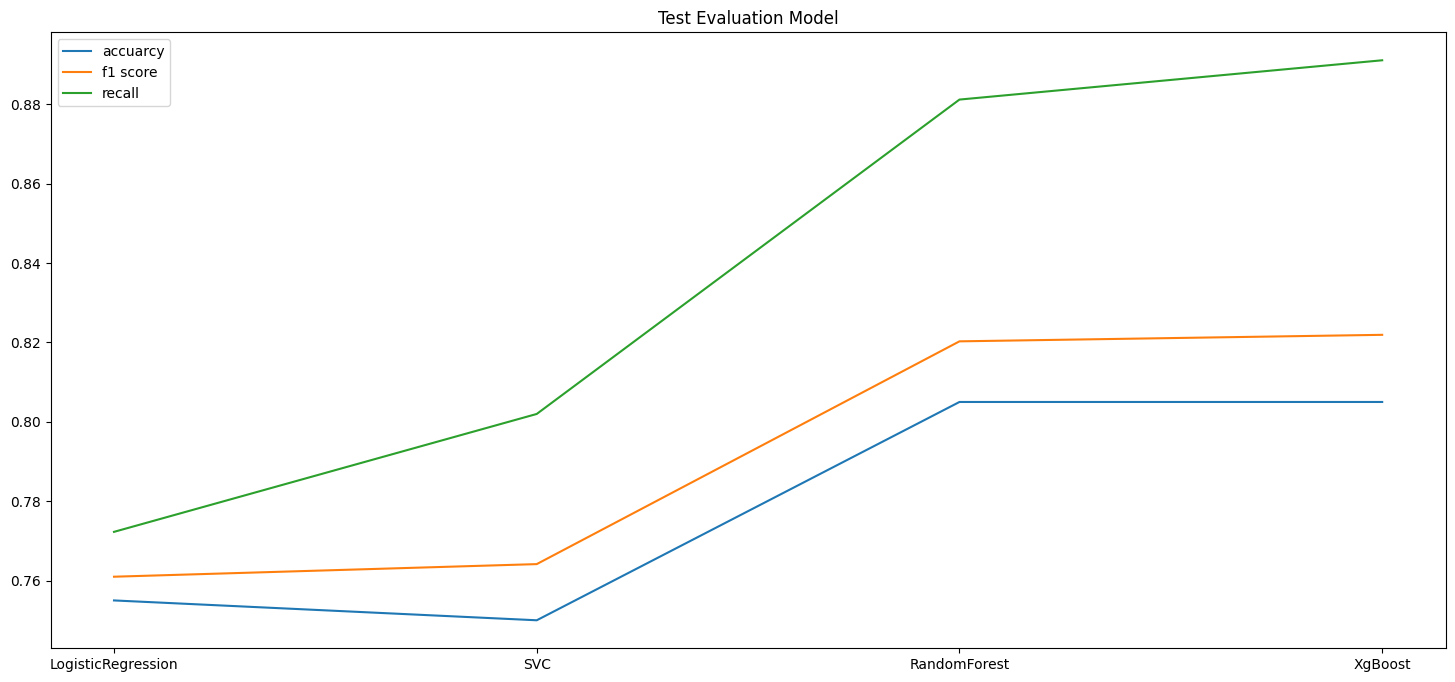

In [124]:
fig,ax = plt.subplots(figsize=(18,8))
plt.plot(models_name, accuarcy_test_score,label='accuarcy')
plt.plot(models_name, f1_test_score,label='f1 score')
plt.plot(models_name, recall_test_score,label='recall')
plt.title('Test Evaluation Model')
plt.legend()
plt.show()

In [125]:
pd.DataFrame({
    'Models':models_name,
    'accuarcy':accuarcy_train_score,
    'f1_score':f1_train_score,
    'recall':recall_train_score,
})

,Models,accuarcy,f1_score,recall
0,LogisticRegression,0.75500,0.748072,0.729323
1,SVC,0.83875,0.839352,0.844612
2,RandomForest,0.99500,0.995012,1.000000
3,XgBoost,0.99250,0.992500,0.994987


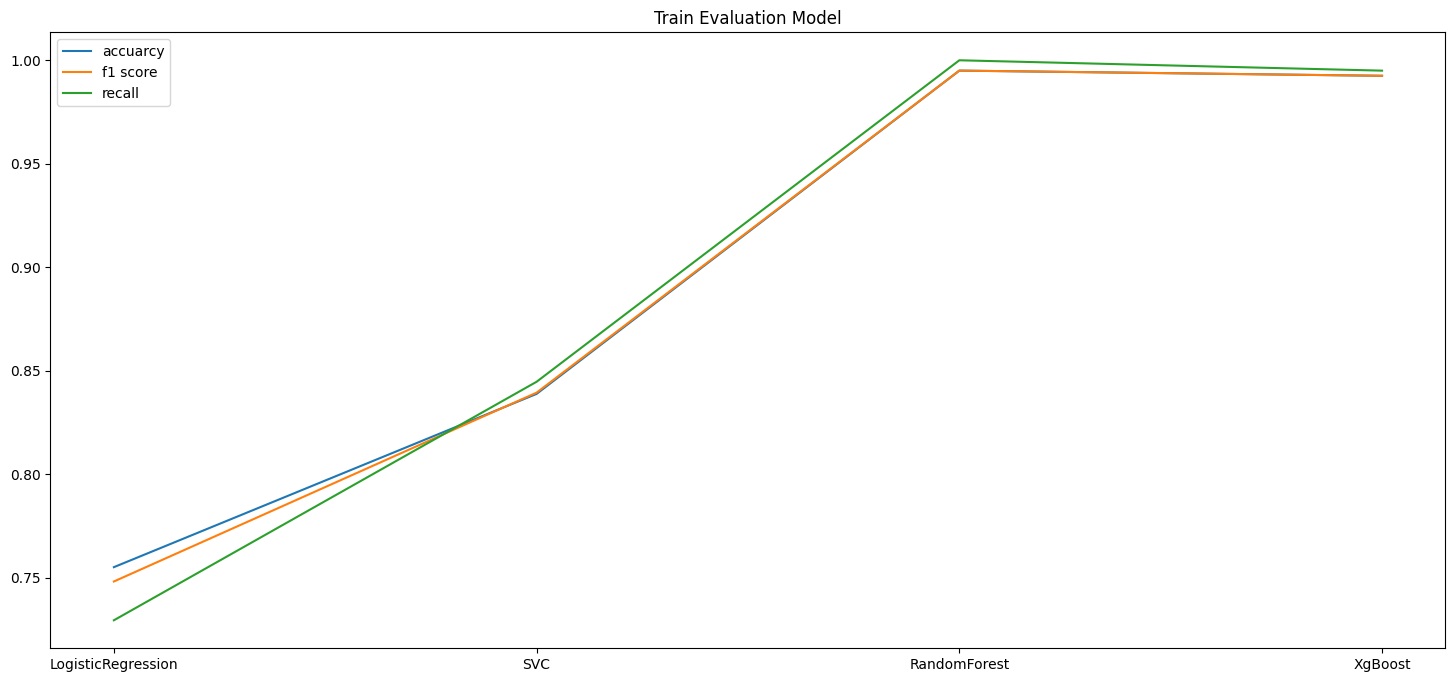

In [126]:
fig,ax = plt.subplots(figsize=(18,8))
plt.plot(models_name, accuarcy_train_score,label='accuarcy')
plt.plot(models_name, f1_train_score,label='f1 score')
plt.plot(models_name, recall_train_score,label='recall')
plt.title('Train Evaluation Model')
plt.legend()
plt.show()